# CS3807 – Deep Learning Laboratory
## Experiment 6: End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

This notebook implements the Experiment 6 workflow from the laboratory manual.

**Required raw HAR representation:** `(N, 128, 9)`.

The notebook automatically:
- locates an uploaded raw UCI HAR ZIP/folder under `/kaggle/input`;
- otherwise attempts the official UCI download;
- extracts 9 raw inertial-signal channels;
- creates a balanced 2400-window laboratory subset;
- uses a 70/15/15 split and training-only normalization;
- trains RNN, LSTM and GRU with the specified common settings;
- generates metrics, confusion matrices and 600-DPI EPS figures;
- studies sequence lengths 32, 64 and 128;
- provides an optional small UCF101 CNN–LSTM section;
- implements synthetic sequence reversal with an encoder–decoder LSTM;
- packages all outputs into a ZIP.

**Important:** the Kaggle `train.csv` / `test.csv` 561-feature dataset is not used because the manual explicitly requires raw inertial signals.

In [3]:
# ============================================================
# 1. Imports, reproducibility and output directories
# ============================================================

import os
import sys
import time
import zipfile
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path("/kaggle/working/experiment6_outputs")
PLOT_DIR = BASE_DIR / "plots"
DATA_DIR = Path("/kaggle/working/uci_har")

BASE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)

def save_plot(fig, name):
    path = PLOT_DIR / f"{name}.eps"
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print("Saved:", path)
    return path

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Output:", BASE_DIR)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Output: /kaggle/working/experiment6_outputs


## 2. Raw UCI HAR dataset

The experiment requires the original UCI HAR `Inertial Signals` files. Each signal file contains 128 measurements per window.

If the raw dataset is not already attached in Kaggle:
1. The cell below attempts the official UCI download.
2. If Kaggle gives `Temporary failure in name resolution`, enable **Internet** in Kaggle Notebook Settings.
3. If Internet still does not work, download `UCI HAR Dataset.zip` on your computer and upload that ZIP using Kaggle's **Add Input / Upload**. The same cell will detect it.

In [4]:
# ============================================================
# 2. Locate / download / extract raw UCI HAR
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
UCI_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00240/"
    "UCI%20HAR%20Dataset.zip"
)

HAR_ROOT = DATA_DIR / "UCI HAR Dataset"
ZIP_PATH = DATA_DIR / "UCI_HAR_Dataset.zip"

def find_raw_roots(base):
    roots = []
    if not base.exists():
        return roots
    for p in base.rglob("*"):
        if p.is_dir() and p.name.lower() == "uci har dataset":
            if (p/"train"/"Inertial Signals").exists():
                roots.append(p)
    return roots

# First look for an already-added raw folder.
roots = find_raw_roots(KAGGLE_INPUT)

if roots:
    HAR_ROOT = roots[0]
    print("Found raw UCI HAR folder:", HAR_ROOT)

else:
    # Look for a user-uploaded ZIP.
    zip_inputs = list(KAGGLE_INPUT.rglob("*.zip")) if KAGGLE_INPUT.exists() else []
    uploaded = next(
        (p for p in zip_inputs
         if any(k in p.name.lower() for k in ["uci", "har", "human"])),
        None
    )

    if uploaded is not None:
        print("Found uploaded ZIP:", uploaded)
        with zipfile.ZipFile(uploaded, "r") as z:
            z.extractall(DATA_DIR)
    else:
        print("No raw UCI HAR input found. Attempting official UCI download...")
        try:
            urllib.request.urlretrieve(UCI_URL, ZIP_PATH)
            print("Downloaded:", ZIP_PATH)
            with zipfile.ZipFile(ZIP_PATH, "r") as z:
                z.extractall(DATA_DIR)
        except Exception as e:
            print("\nDOWNLOAD FAILED:", repr(e))
            print("\nIf this is a DNS/network error:")
            print("  Kaggle Notebook -> Settings -> Internet -> ON")
            print("or upload UCI HAR Dataset.zip through Kaggle Input.")
            raise

    roots = find_raw_roots(DATA_DIR)
    if roots:
        HAR_ROOT = roots[0]
    elif (DATA_DIR/"UCI HAR Dataset").exists():
        HAR_ROOT = DATA_DIR/"UCI HAR Dataset"
    else:
        raise FileNotFoundError(
            "Could not find 'UCI HAR Dataset/train/Inertial Signals'."
        )

TRAIN_SIGNAL_DIR = HAR_ROOT / "train" / "Inertial Signals"
TEST_SIGNAL_DIR = HAR_ROOT / "test" / "Inertial Signals"

required = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

for split, folder in [("train", TRAIN_SIGNAL_DIR), ("test", TEST_SIGNAL_DIR)]:
    for channel in required:
        p = folder / f"{channel}_{split}.txt"
        if not p.exists():
            raise FileNotFoundError(p)

print("\nRAW UCI HAR READY")
print("Root:", HAR_ROOT)
print("Train signals:", TRAIN_SIGNAL_DIR)
print("Test signals :", TEST_SIGNAL_DIR)

No raw UCI HAR input found. Attempting official UCI download...
Downloaded: /kaggle/working/uci_har/UCI_HAR_Dataset.zip

RAW UCI HAR READY
Root: /kaggle/working/uci_har/UCI HAR Dataset
Train signals: /kaggle/working/uci_har/UCI HAR Dataset/train/Inertial Signals
Test signals : /kaggle/working/uci_har/UCI HAR Dataset/test/Inertial Signals


In [5]:
# ============================================================
# 3. Load raw signals -> (N, 128, 9)
# ============================================================

CHANNELS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

def load_har_split(split):
    folder = HAR_ROOT / split / "Inertial Signals"
    arrays = []
    for channel in CHANNELS:
        arr = np.loadtxt(folder / f"{channel}_{split}.txt")
        assert arr.shape[1] == 128, arr.shape
        arrays.append(arr)

    # (N, 9, 128) -> (N, 128, 9)
    X = np.transpose(np.stack(arrays, axis=1), (0, 2, 1))
    y = np.loadtxt(
        HAR_ROOT / split / f"y_{split}.txt",
        dtype=np.int64
    ) - 1
    return X.astype(np.float32), y

X_train_full, y_train_full = load_har_split("train")
X_test_official, y_test_official = load_har_split("test")

print("Full train:", X_train_full.shape, y_train_full.shape)
print("Full test :", X_test_official.shape, y_test_official.shape)
assert X_train_full.shape[1:] == (128, 9)
assert X_test_official.shape[1:] == (128, 9)

Full train: (7352, 128, 9) (7352,)
Full test : (2947, 128, 9) (2947,)


In [6]:
# ============================================================
# 4. Balanced 2400-window laboratory subset
# ============================================================

SAMPLES_PER_CLASS = 400
subset_idx = []

for class_id in range(6):
    idx = np.where(y_train_full == class_id)[0]
    rng = np.random.default_rng(SEED + class_id)
    subset_idx.extend(
        rng.choice(idx, SAMPLES_PER_CLASS, replace=False)
    )

subset_idx = np.array(subset_idx)
np.random.default_rng(SEED).shuffle(subset_idx)

X_subset = X_train_full[subset_idx]
y_subset = y_train_full[subset_idx]

print("Subset:", X_subset.shape)
for i, name in enumerate(ACTIVITY_NAMES):
    print(name, np.sum(y_subset == i))

Subset: (2400, 128, 9)
WALKING 400
WALKING_UPSTAIRS 400
WALKING_DOWNSTAIRS 400
SITTING 400
STANDING 400
LAYING 400


In [7]:
# ============================================================
# 5. 70 / 15 / 15 split + training-only normalization
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_subset,
    test_size=0.30,
    random_state=SEED,
    stratify=y_subset
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
std = np.where(std < 1e-8, 1.0, std)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)
print("Classes    :", len(ACTIVITY_NAMES))
print("Features   :", X_train.shape[-1])
print("Sequence T :", X_train.shape[1])

for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(name, np.bincount(y, minlength=6))

Training   : (1680, 128, 9)
Validation : (360, 128, 9)
Testing    : (360, 128, 9)
Classes    : 6
Features   : 9
Sequence T : 128
Train [280 280 280 280 280 280]
Val [60 60 60 60 60 60]
Test [60 60 60 60 60 60]


## Plot 1 — Temporal sensor visualization

Three activity classes and three representative sensor channels are plotted over all 128 time steps.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot1_temporal_sensor_visualization.eps


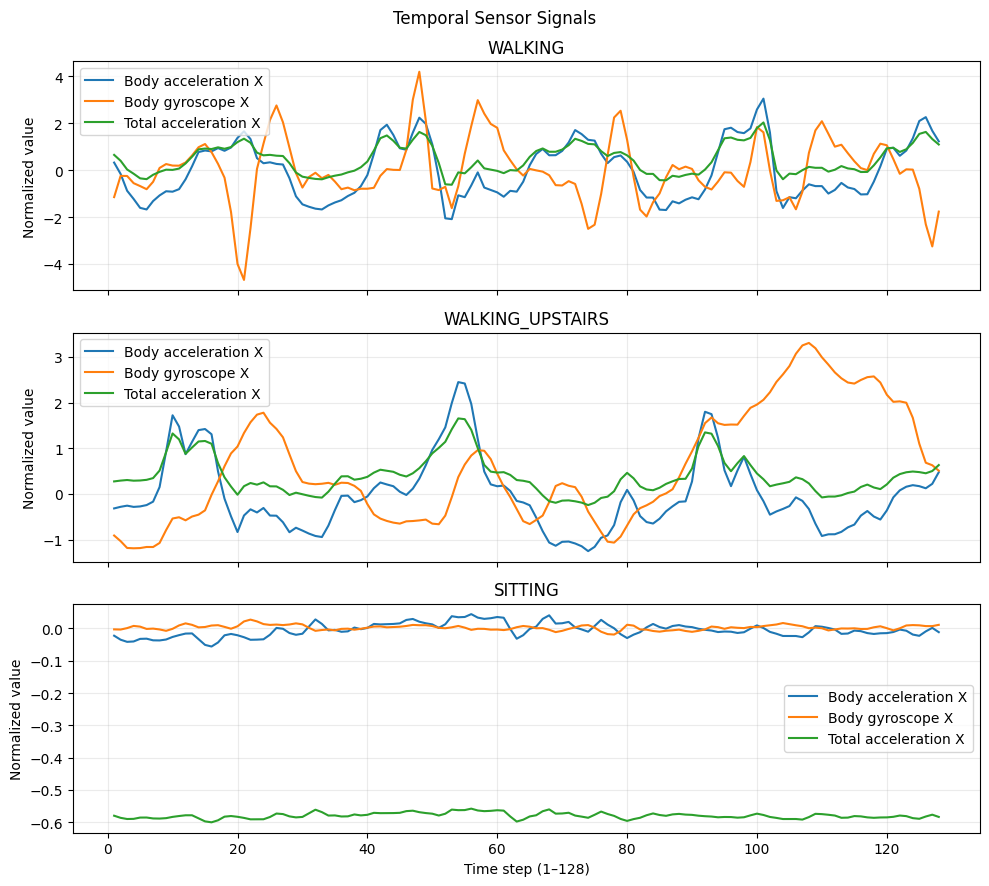

In [8]:
# ============================================================
# 6. Plot 1 — temporal sensor signals
# ============================================================

classes_to_plot = [0, 1, 3]
channels_to_plot = [0, 3, 6]
channel_names = [
    "Body acceleration X", "Body acceleration Y", "Body acceleration Z",
    "Body gyroscope X", "Body gyroscope Y", "Body gyroscope Z",
    "Total acceleration X", "Total acceleration Y", "Total acceleration Z",
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
t = np.arange(1, 129)

for ax, cls in zip(axes, classes_to_plot):
    idx = np.where(y_train == cls)[0][0]
    for ch in channels_to_plot:
        ax.plot(t, X_train[idx, :, ch], label=channel_names[ch])
    ax.set_title(ACTIVITY_NAMES[cls])
    ax.set_ylabel("Normalized value")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Time step (1–128)")
fig.suptitle("Temporal Sensor Signals")
fig.tight_layout()
save_plot(fig, "plot1_temporal_sensor_visualization")
plt.show()
plt.close(fig)

### Plot 1 inference

The measurements vary across time and show activity-dependent temporal patterns. This supports using sequence models because the ordering of measurements carries information about the performed activity.

## Numerical Vanilla RNN / BPTT exercise

Given `x1=0.5`, `x2=0.7`, `x3=0.2`, `h0=0`, `Wx=0.5`, `Wh=0.8`, `b=0.1`, calculate:

`h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)`

In [9]:
# ============================================================
# 7. Numerical RNN exercise
# ============================================================

x = [0.5, 0.7, 0.2]
h = 0.0

for t, xt in enumerate(x, 1):
    h = np.tanh(0.5 * xt + 0.8 * h + 0.1)
    print(f"h{t} = {h:.6f}")

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


## RNN / LSTM / GRU classification

All models use the same classifier settings. Only the recurrent layer changes:

- recurrent units: 32
- dropout: 0.2
- Dense: 16 ReLU
- output: 6-class softmax
- optimizer: Adam, learning rate `1e-3`
- batch size: 32
- epochs: 30
- loss: sparse categorical crossentropy

In [10]:
# ============================================================
# 8. Model builders
# ============================================================

N_CLASSES = 6
BATCH_SIZE = 32
EPOCHS = 30

def build_model(kind, T=128):
    if kind == "RNN":
        recurrent = layers.SimpleRNN(32)
    elif kind == "LSTM":
        recurrent = layers.LSTM(32)
    elif kind == "GRU":
        recurrent = layers.GRU(32)
    else:
        raise ValueError(kind)

    model = models.Sequential([
        layers.Input(shape=(T, 9)),
        recurrent,
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(6, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [11]:
# ============================================================
# 9. Train RNN, LSTM and GRU
# ============================================================

models_dict = {}
histories = {}
training_times = {}

for kind in ["RNN", "LSTM", "GRU"]:
    print("\n" + "="*70)
    print("TRAINING", kind)
    print("="*70)

    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_model(kind)
    start = time.perf_counter()

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )

    elapsed = time.perf_counter() - start

    models_dict[kind] = model
    histories[kind] = hist.history
    training_times[kind] = elapsed

    print(f"{kind} time: {elapsed:.2f} s")
    print(f"{kind} parameters: {model.count_params()}")


TRAINING RNN


I0000 00:00:1790172452.760342      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790172452.763263      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30
19/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2145 - loss: 1.8692

I0000 00:00:1790172457.558016     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.3226 - loss: 1.6784 - val_accuracy: 0.5083 - val_loss: 1.4284
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5232 - loss: 1.3008 - val_accuracy: 0.5639 - val_loss: 1.1290
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5714 - loss: 1.0778 - val_accuracy: 0.5972 - val_loss: 0.9518
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6071 - loss: 0.9496 - val_accuracy: 0.6222 - val_loss: 0.8237
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6107 - loss: 0.8550 - val_accuracy: 0.6222 - val_loss: 0.7955
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6452 - loss: 0.7903 - val_accuracy: 0.6639 - val_loss: 0.7076
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6637 - loss: 0.7434 - val_accuracy: 0.6917 - val_loss: 0.6670
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6929 - loss: 0.6945 - val_accuracy: 0.7194 - val_loss: 0.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot2_rnn_loss.eps


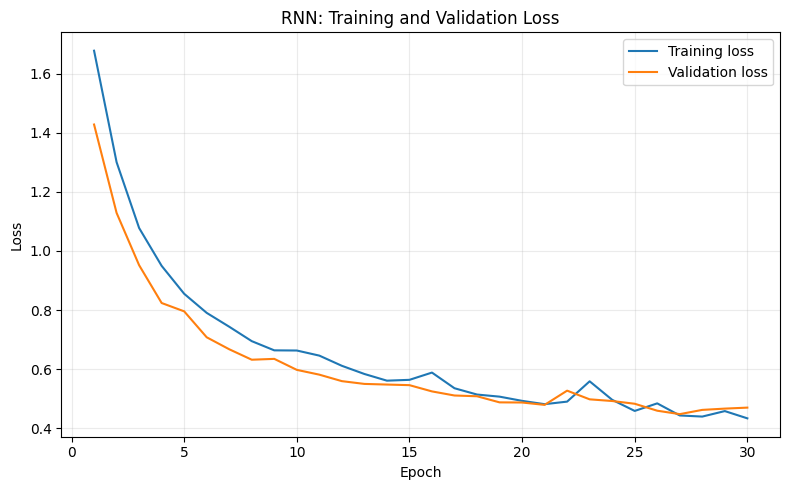

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot3_rnn_accuracy.eps


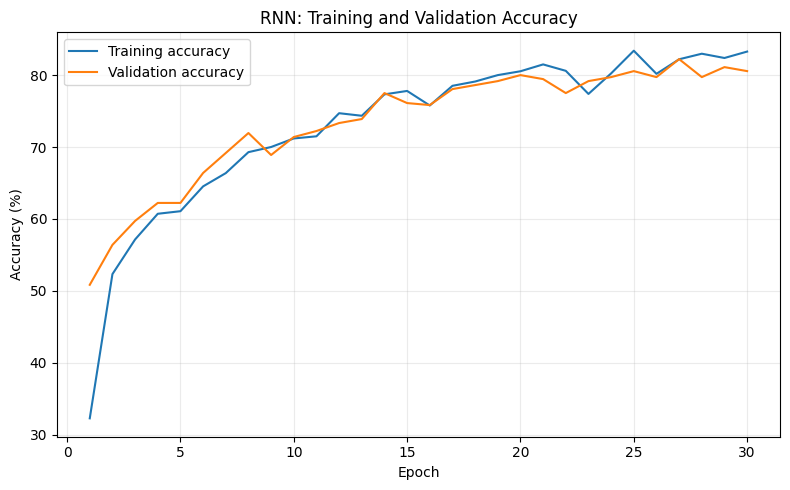

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot2_lstm_loss.eps


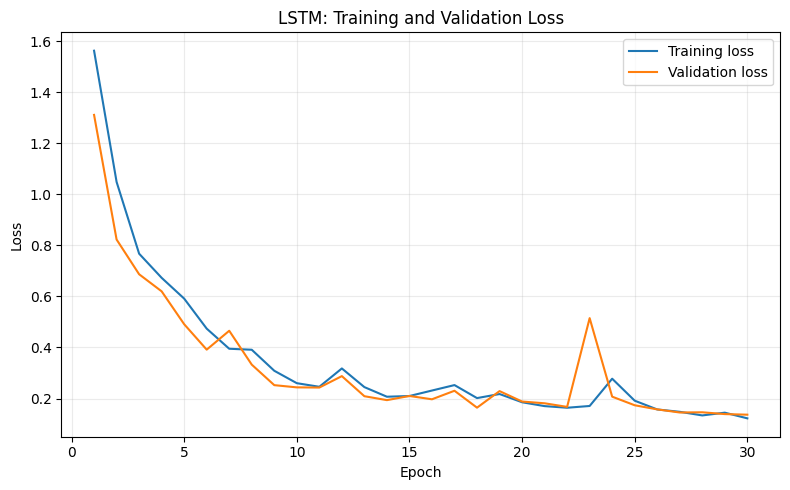

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot3_lstm_accuracy.eps


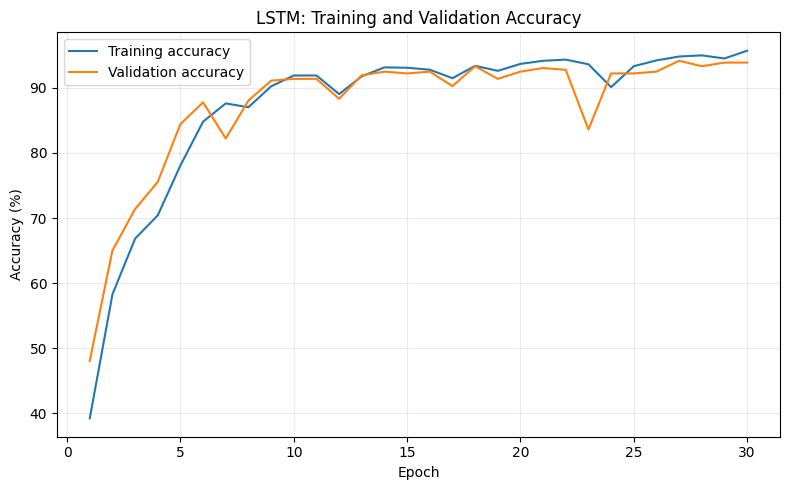

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot2_gru_loss.eps


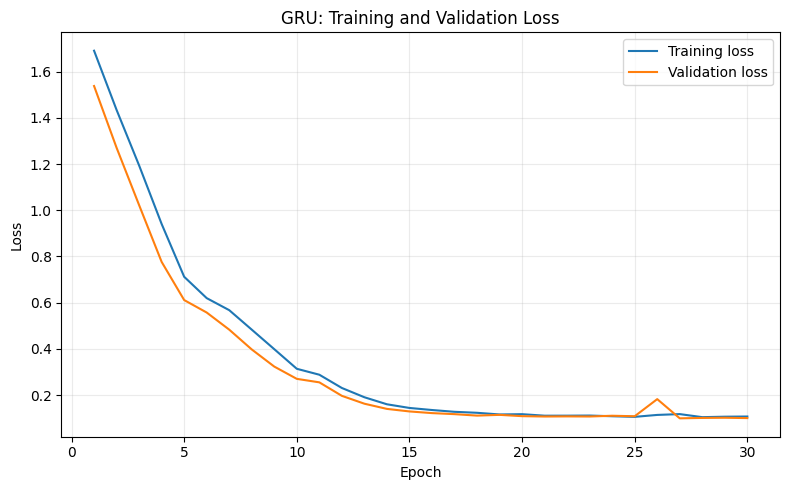

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot3_gru_accuracy.eps


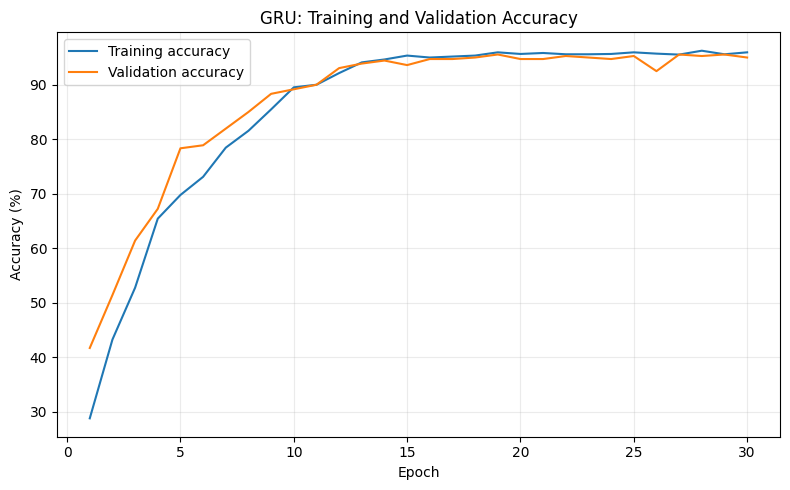

In [12]:
# ============================================================
# 10. Plot 2 & Plot 3 — loss and accuracy
# ============================================================

for kind in ["RNN", "LSTM", "GRU"]:
    h = histories[kind]
    e = np.arange(1, len(h["loss"]) + 1)

    fig, ax = plt.subplots()
    ax.plot(e, h["loss"], label="Training loss")
    ax.plot(e, h["val_loss"], label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{kind}: Training and Validation Loss")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_plot(fig, f"plot2_{kind.lower()}_loss")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots()
    ax.plot(e, np.array(h["accuracy"])*100, label="Training accuracy")
    ax.plot(e, np.array(h["val_accuracy"])*100, label="Validation accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{kind}: Training and Validation Accuracy")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_plot(fig, f"plot3_{kind.lower()}_accuracy")
    plt.show()
    plt.close(fig)

Saved: /kaggle/working/experiment6_outputs/plots/plot4_rnn_confusion_matrix.eps


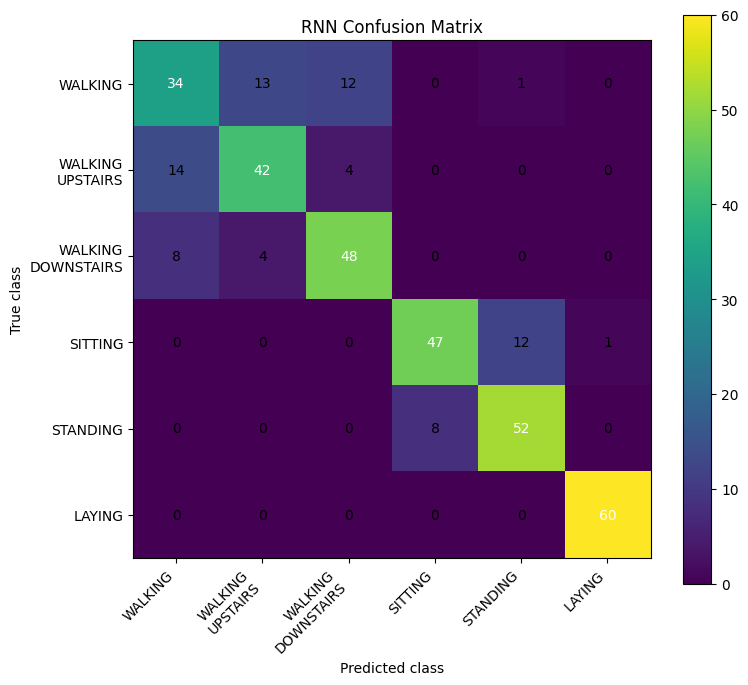

Saved: /kaggle/working/experiment6_outputs/plots/plot4_lstm_confusion_matrix.eps


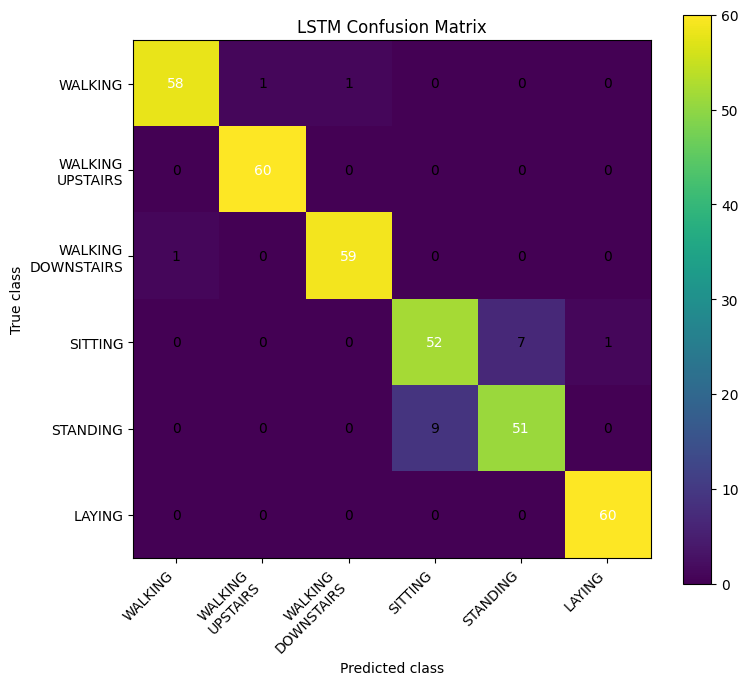

Saved: /kaggle/working/experiment6_outputs/plots/plot4_gru_confusion_matrix.eps


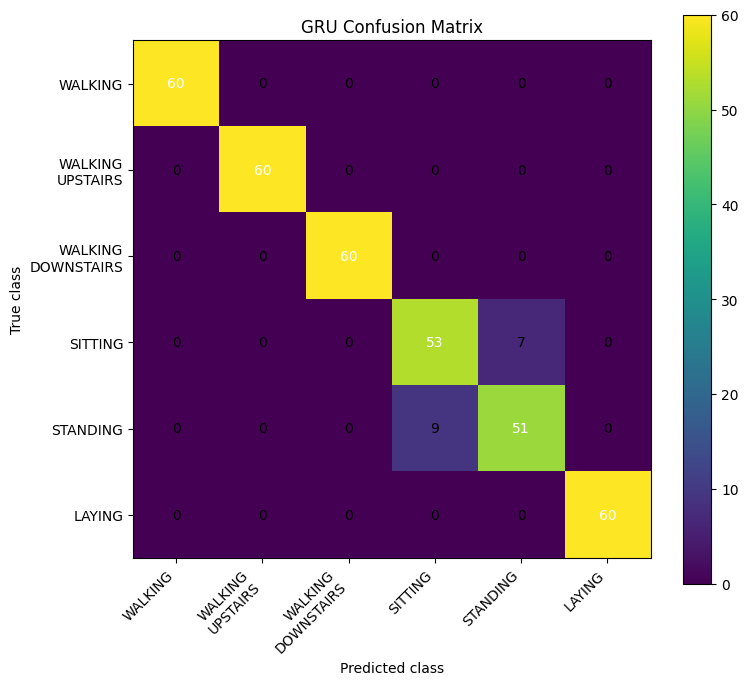

Model  Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  Parameters  Training Time (s)
  RNN     78.611111            78.452655         78.611111     78.456827        1974          23.818692
 LSTM     94.444444            94.422778         94.444444     94.425087        6006          20.208337
  GRU     95.555556            95.569151         95.555556     95.554321        4758          17.754757


In [13]:
# ============================================================
# 11. Test metrics + confusion matrices
# ============================================================

rows = []

for kind, model in models_dict.items():
    pred = np.argmax(
        model.predict(X_test, batch_size=BATCH_SIZE, verbose=0),
        axis=1
    )

    acc = accuracy_score(y_test, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )

    rows.append({
        "Model": kind,
        "Accuracy (%)": acc*100,
        "Macro Precision (%)": precision*100,
        "Macro Recall (%)": recall*100,
        "Macro F1 (%)": f1*100,
        "Parameters": models_dict[kind].count_params(),
        "Training Time (s)": training_times[kind],
    })

    cm = confusion_matrix(y_test, pred, labels=np.arange(6))

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm)
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels([x.replace("_", "\n") for x in ACTIVITY_NAMES], rotation=45, ha="right")
    ax.set_yticklabels([x.replace("_", "\n") for x in ACTIVITY_NAMES])

    threshold = cm.max()/2
    for i in range(6):
        for j in range(6):
            ax.text(
                j, i, str(cm[i,j]),
                ha="center", va="center",
                color="white" if cm[i,j] > threshold else "black"
            )

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"{kind} Confusion Matrix")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    save_plot(fig, f"plot4_{kind.lower()}_confusion_matrix")
    plt.show()
    plt.close(fig)

results_df = pd.DataFrame(rows)
results_df.to_csv(BASE_DIR/"recurrent_model_results.csv", index=False)
print(results_df.to_string(index=False))

In [14]:
# ============================================================
# 12. Data-driven confusion-matrix observations
# ============================================================

for kind, model in models_dict.items():
    pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, pred, labels=np.arange(6))

    recall_by_class = np.divide(
        np.diag(cm), cm.sum(axis=1),
        out=np.zeros(6, dtype=float),
        where=cm.sum(axis=1) != 0
    )

    best = int(np.argmax(recall_by_class))
    worst = int(np.argmin(recall_by_class))

    off = cm.copy()
    np.fill_diagonal(off, 0)
    pair = np.unravel_index(np.argmax(off), off.shape)

    print("\n", kind)
    print("Highest class recall:", ACTIVITY_NAMES[best], f"{recall_by_class[best]*100:.2f}%")
    print("Lowest class recall :", ACTIVITY_NAMES[worst], f"{recall_by_class[worst]*100:.2f}%")
    print(
        "Largest off-diagonal confusion:",
        ACTIVITY_NAMES[pair[0]], "->", ACTIVITY_NAMES[pair[1]],
        f"({cm[pair]} samples)"
    )


 RNN
Highest class recall: LAYING 100.00%
Lowest class recall : WALKING 56.67%
Largest off-diagonal confusion: WALKING_UPSTAIRS -> WALKING (14 samples)

 LSTM
Highest class recall: WALKING_UPSTAIRS 100.00%
Lowest class recall : STANDING 85.00%
Largest off-diagonal confusion: STANDING -> SITTING (9 samples)

 GRU
Highest class recall: WALKING 100.00%
Lowest class recall : STANDING 85.00%
Largest off-diagonal confusion: STANDING -> SITTING (9 samples)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/plot5_model_performance_comparison.eps


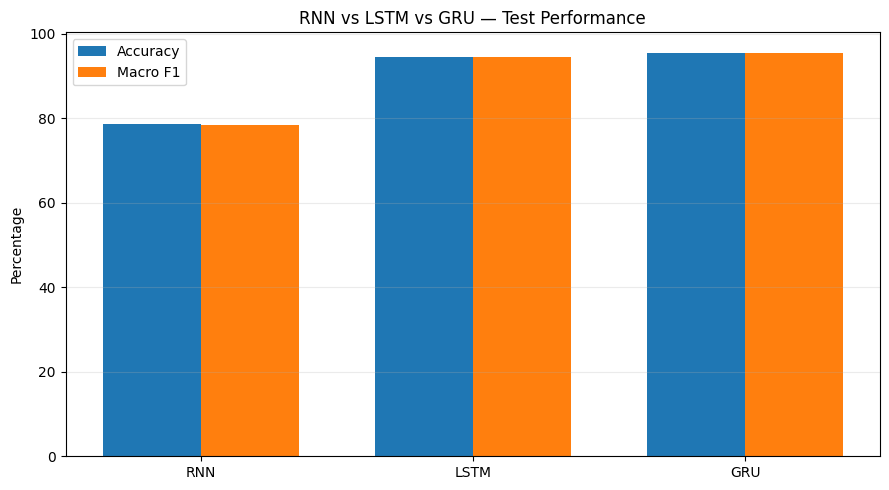

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /kaggle/working/experiment6_outputs/plots/model_complexity_and_training_time.eps


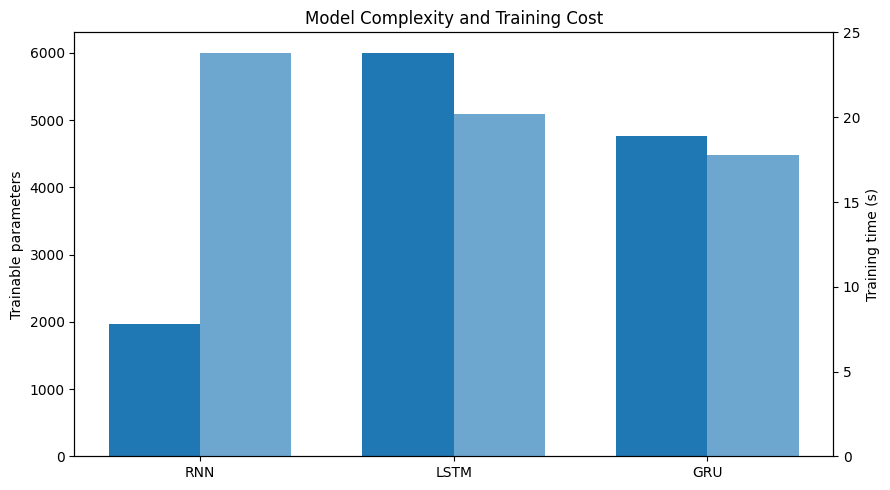

In [15]:
# ============================================================
# 13. Plot 5 — performance comparison
# ============================================================

x = np.arange(len(results_df))
w = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-w/2, results_df["Accuracy (%)"], w, label="Accuracy")
ax.bar(x+w/2, results_df["Macro F1 (%)"], w, label="Macro F1")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"])
ax.set_ylabel("Percentage")
ax.set_title("RNN vs LSTM vs GRU — Test Performance")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
save_plot(fig, "plot5_model_performance_comparison")
plt.show()
plt.close(fig)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(x-w/2, results_df["Parameters"], w, label="Parameters")
ax1.set_ylabel("Trainable parameters")
ax1.set_xticks(x)
ax1.set_xticklabels(results_df["Model"])

ax2 = ax1.twinx()
ax2.bar(x+w/2, results_df["Training Time (s)"], w, alpha=0.65, label="Training time")
ax2.set_ylabel("Training time (s)")
ax1.set_title("Model Complexity and Training Cost")
fig.tight_layout()
save_plot(fig, "model_complexity_and_training_time")
plt.show()
plt.close(fig)

## Plot 5 inference

Use the generated table to discuss the measured trade-off among predictive performance, parameter count and training cost. The notebook does not assume a winner; the conclusion should be based on the actual execution.


SEQUENCE LENGTH: 32

SEQUENCE LENGTH: 64

SEQUENCE LENGTH: 128


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 Sequence Length Model  Macro F1 (%)  Training Time (s)
              32   RNN     82.954576          16.558272
              32  LSTM     92.490173          14.335124
              32   GRU     91.938545          14.088723
              64   RNN     81.242172          17.329762
              64  LSTM     93.322389          15.537273
              64   GRU     95.555247          15.261484
             128   RNN     76.038795          22.916406
             128  LSTM     93.865371          18.161374
             128   GRU     95.833044          17.681339
Saved: /kaggle/working/experiment6_outputs/plots/plot6_sequence_length_vs_f1.eps


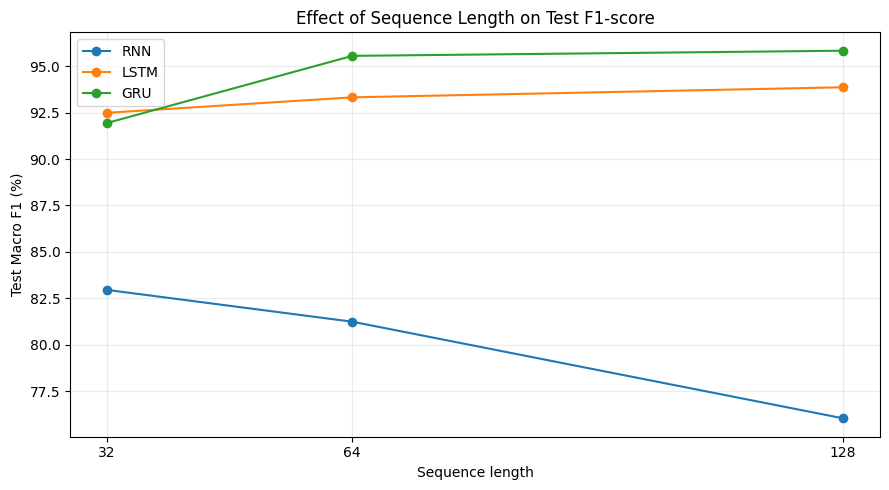

In [16]:
# ============================================================
# 14. Plot 6 — sequence length experiment
# ============================================================

SEQUENCE_LENGTHS = [32, 64, 128]
SEQ_EPOCHS = 30
sequence_rows = []

for T in SEQUENCE_LENGTHS:
    print("\nSEQUENCE LENGTH:", T)

    for kind in ["RNN", "LSTM", "GRU"]:
        tf.keras.backend.clear_session()
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model = build_model(kind, T=T)
        start = time.perf_counter()

        model.fit(
            X_train[:, :T, :], y_train,
            validation_data=(X_val[:, :T, :], y_val),
            epochs=SEQ_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
        )

        elapsed = time.perf_counter() - start

        pred = np.argmax(
            model.predict(X_test[:, :T, :], verbose=0),
            axis=1
        )

        _, _, f1, _ = precision_recall_fscore_support(
            y_test, pred, average="macro", zero_division=0
        )

        sequence_rows.append({
            "Sequence Length": T,
            "Model": kind,
            "Macro F1 (%)": f1*100,
            "Training Time (s)": elapsed,
        })

sequence_df = pd.DataFrame(sequence_rows)
sequence_df.to_csv(BASE_DIR/"sequence_length_results.csv", index=False)
print(sequence_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
for kind in ["RNN", "LSTM", "GRU"]:
    s = sequence_df[sequence_df["Model"] == kind]
    ax.plot(s["Sequence Length"], s["Macro F1 (%)"], marker="o", label=kind)

ax.set_xlabel("Sequence length")
ax.set_ylabel("Test Macro F1 (%)")
ax.set_title("Effect of Sequence Length on Test F1-score")
ax.set_xticks(SEQUENCE_LENGTHS)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_plot(fig, "plot6_sequence_length_vs_f1")
plt.show()
plt.close(fig)

# Task 7 — Optional CNN–LSTM video understanding

The manual specifies a small UCF101 subset with 3–5 classes, 10 uniformly sampled frames, 224×224 RGB frames, a frozen pretrained CNN such as MobileNetV2, and an LSTM/GRU recurrent classifier.

Because the complete UCF101 dataset is very large, this notebook expects a **small UCF101 subset** to be added through Kaggle Input. The expected folder names for this implementation are:

```text
Basketball/
Biking/
TennisSwing/
```

If it is not present, the video section skips cleanly while the required HAR experiment still runs.

In [17]:
# ============================================================
# 15. Locate optional UCF101 subset
# ============================================================

import cv2

VIDEO_CLASSES = ["Basketball", "Biking", "TennisSwing"]
VIDEO_ROOT = None

if KAGGLE_INPUT.exists():
    for root, dirs, files in os.walk(KAGGLE_INPUT):
        root = Path(root)
        if all((root/c).is_dir() for c in VIDEO_CLASSES):
            VIDEO_ROOT = root
            break

if VIDEO_ROOT:
    print("Video dataset:", VIDEO_ROOT)
    for c in VIDEO_CLASSES:
        n = len([
            p for p in (VIDEO_ROOT/c).glob("*")
            if p.suffix.lower() in {".avi",".mp4",".mov",".mkv"}
        ])
        print(c, n, "videos")
else:
    print("No small UCF101 subset found. Video cells will be skipped.")

No small UCF101 subset found. Video cells will be skipped.


In [18]:
# ============================================================
# 16. Video frames -> MobileNetV2 features -> LSTM
# ============================================================

def sample_video_frames(path, n=10, size=(224,224)):
    cap = cv2.VideoCapture(str(path))
    count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if count <= 0:
        cap.release()
        raise RuntimeError(f"No frames: {path}")

    indices = np.linspace(0, count-1, n).astype(int)
    frames = []

    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, frame = cap.read()
        if not ok:
            cap.release()
            raise RuntimeError(f"Could not read frame {i}: {path}")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frames.append(frame)

    cap.release()
    return np.asarray(frames, dtype=np.uint8)

if VIDEO_ROOT:
    video_paths = []
    video_labels = []

    for label, cls in enumerate(VIDEO_CLASSES):
        files = sorted([
            p for p in (VIDEO_ROOT/cls).glob("*")
            if p.suffix.lower() in {".avi",".mp4",".mov",".mkv"}
        ])[:8]
        for p in files:
            video_paths.append(p)
            video_labels.append(label)

    # Plot 7
    sample_frames = sample_video_frames(video_paths[0])
    fig, axes = plt.subplots(2,5,figsize=(15,6))
    for ax, frame, i in zip(axes.ravel(), sample_frames, range(10)):
        ax.imshow(frame)
        ax.set_title(f"Frame {i+1}")
        ax.axis("off")
    fig.suptitle(f"Video sample — {VIDEO_CLASSES[video_labels[0]]}")
    fig.tight_layout()
    save_plot(fig, "plot7_video_sample_frames")
    plt.show()
    plt.close(fig)

    cnn = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(224,224,3)
    )
    cnn.trainable = False

    feature_list = []
    label_list = []

    for path, label in zip(video_paths, video_labels):
        frames = sample_video_frames(path).astype(np.float32)
        frames = tf.keras.applications.mobilenet_v2.preprocess_input(frames)
        feats = cnn.predict(frames, verbose=0)
        feature_list.append(feats)
        label_list.append(label)

    X_video = np.stack(feature_list)
    y_video = np.asarray(label_list)

    print("CNN feature dimension:", X_video.shape[-1])
    print("Recurrent input:", X_video.shape)

    Xv_train, Xv_test, yv_train, yv_test = train_test_split(
        X_video, y_video,
        test_size=0.30,
        random_state=SEED,
        stratify=y_video
    )

    video_model = models.Sequential([
        layers.Input(shape=(10, X_video.shape[-1])),
        layers.LSTM(32),
        layers.Dense(3, activation="softmax"),
    ])

    video_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    video_history = video_model.fit(
        Xv_train, yv_train,
        validation_split=0.20,
        epochs=20,
        batch_size=4,
        verbose=1
    )

    video_pred = np.argmax(video_model.predict(Xv_test, verbose=0), axis=1)

    vp, vr, vf1, _ = precision_recall_fscore_support(
        yv_test, video_pred, average="macro", zero_division=0
    )

    print("Video accuracy:", accuracy_score(yv_test, video_pred))
    print("Video macro precision:", vp)
    print("Video macro recall:", vr)
    print("Video macro F1:", vf1)
    print("Video parameters:", video_model.count_params())

    # Plot 8
    h = video_history.history
    e = np.arange(1, len(h["loss"])+1)

    fig, ax = plt.subplots()
    ax.plot(e, np.array(h["accuracy"])*100, label="Training accuracy")
    ax.plot(e, np.array(h["val_accuracy"])*100, label="Validation accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("CNN–LSTM Video Accuracy")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_plot(fig, "plot8_video_accuracy")
    plt.show()
    plt.close(fig)

    # Video confusion matrix
    cm = confusion_matrix(yv_test, video_pred, labels=np.arange(3))
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(VIDEO_CLASSES, rotation=35, ha="right")
    ax.set_yticklabels(VIDEO_CLASSES)
    for i in range(3):
        for j in range(3):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title("CNN–LSTM Video Confusion Matrix")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    save_plot(fig, "plot9_video_confusion_matrix")
    plt.show()
    plt.close(fig)

else:
    print("Video section skipped.")

Video section skipped.


# Task 8 — Synthetic sequence-to-sequence reversal

Example:

`[3, 8, 1, 5] → [5, 1, 8, 3]`

The model uses an encoder LSTM and decoder LSTM with teacher forcing. Both token accuracy and complete sequence accuracy are reported.

In [19]:
# ============================================================
# 17. Seq2seq reversal dataset
# ============================================================

VOCAB_SIZE = 10
SEQ_LEN = 5
N_SEQ = 4000

rng = np.random.default_rng(SEED)
X_seq = rng.integers(1, VOCAB_SIZE, size=(N_SEQ, SEQ_LEN))
Y_seq = X_seq[:, ::-1]

START = 0
D_seq = np.zeros_like(Y_seq)
D_seq[:,0] = START
D_seq[:,1:] = Y_seq[:,:-1]

Xtr, Xtmp, Dtr, Dtmp, Ytr, Ytmp = train_test_split(
    X_seq, D_seq, Y_seq,
    test_size=0.30, random_state=SEED
)
Xv, Xte, Dv, Dte, Yv, Yte = train_test_split(
    Xtmp, Dtmp, Ytmp,
    test_size=0.50, random_state=SEED
)

for i in range(5):
    print(X_seq[i].tolist(), "->", Y_seq[i].tolist())

[1, 7, 6, 4, 4] -> [4, 4, 6, 7, 1]
[8, 1, 7, 2, 1] -> [1, 2, 7, 1, 8]
[5, 9, 7, 7, 7] -> [7, 7, 7, 9, 5]
[8, 5, 2, 8, 5] -> [5, 8, 2, 5, 8]
[5, 4, 2, 9, 8] -> [8, 9, 2, 4, 5]


Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2446 - loss: 2.0689 - val_accuracy: 0.3627 - val_loss: 1.6565
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5075 - loss: 1.2970 - val_accuracy: 0.6907 - val_loss: 0.9091
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8314 - loss: 0.6350 - val_accuracy: 0.9167 - val_loss: 0.4336
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9554 - loss: 0.3104 - val_accuracy: 0.9790 - val_loss: 0.2335
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9856 - loss: 0.1808 - val_accuracy: 0.9793 - val_loss: 0.1654
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9937 - loss: 0.1208 - val_accuracy: 0.9913 - val_loss: 0.1110
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9967 - loss: 0.0862 - val_accuracy: 0.9957 - val_loss: 0.0756
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9983 - loss: 0.0651 - val_accuracy: 0.9970 - val_loss

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Token accuracy: 0.9993333333333333
Sequence accuracy: 0.9966666666666667

Input:     [1, 9, 9, 2, 3]
Expected:  [3, 2, 9, 9, 1]
Predicted: [3, 2, 9, 9, 1]

Input:     [5, 7, 7, 6, 6]
Expected:  [6, 6, 7, 7, 5]
Predicted: [6, 6, 7, 7, 5]

Input:     [9, 3, 4, 4, 9]
Expected:  [9, 4, 4, 3, 9]
Predicted: [9, 4, 4, 3, 9]

Input:     [4, 7, 5, 9, 7]
Expected:  [7, 9, 5, 7, 4]
Predicted: [7, 9, 5, 7, 4]

Input:     [1, 6, 2, 3, 2]
Expected:  [2, 3, 2, 6, 1]
Predicted: [2, 3, 2, 6, 1]
Saved: /kaggle/working/experiment6_outputs/plots/seq2seq_training_validation_loss.eps


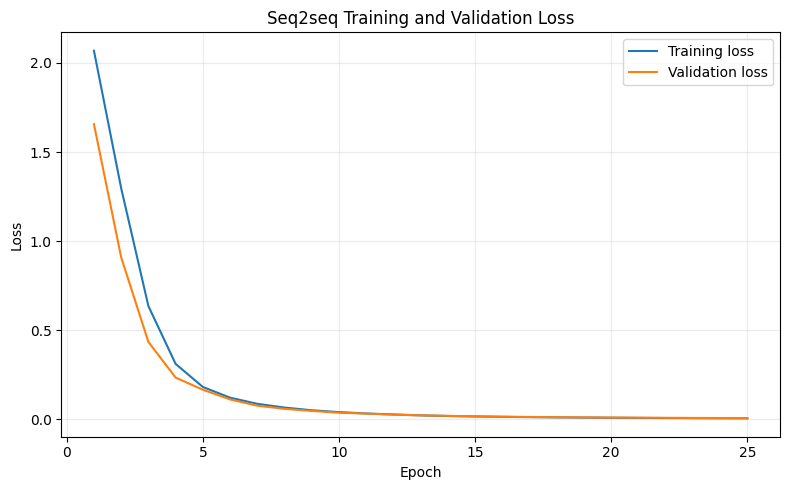

In [20]:
# ============================================================
# 18. Encoder-decoder LSTM
# ============================================================

EMBED = 32
LATENT = 64

class Seq2Seq(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = layers.Embedding(VOCAB_SIZE, EMBED)
        self.encoder = layers.LSTM(LATENT, return_state=True)
        self.decoder = layers.LSTM(LATENT, return_sequences=True)
        self.output_layer = layers.Dense(VOCAB_SIZE, activation="softmax")

    def call(self, inputs, training=False):
        enc_in, dec_in = inputs
        _, h, c = self.encoder(self.embedding(enc_in), training=training)
        dec_out = self.decoder(
            self.embedding(dec_in),
            initial_state=[h,c],
            training=training
        )
        return self.output_layer(dec_out)

seq_model = Seq2Seq()
seq_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq_history = seq_model.fit(
    (Xtr, Dtr), Ytr,
    validation_data=((Xv, Dv), Yv),
    epochs=25,
    batch_size=32,
    verbose=1
)

prob = seq_model.predict((Xte,Dte), verbose=0)
pred = np.argmax(prob, axis=-1)

token_acc = np.mean(pred == Yte)
sequence_acc = np.mean(np.all(pred == Yte, axis=1))

print("Token accuracy:", token_acc)
print("Sequence accuracy:", sequence_acc)

for i in range(5):
    print("\nInput:    ", Xte[i].tolist())
    print("Expected: ", Yte[i].tolist())
    print("Predicted:", pred[i].tolist())

pd.DataFrame([{
    "Token Accuracy (%)": token_acc*100,
    "Sequence Accuracy (%)": sequence_acc*100,
    "Parameters": seq_model.count_params()
}]).to_csv(BASE_DIR/"seq2seq_results.csv", index=False)

h = seq_history.history
e = np.arange(1, len(h["loss"])+1)
fig, ax = plt.subplots()
ax.plot(e,h["loss"],label="Training loss")
ax.plot(e,h["val_loss"],label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Seq2seq Training and Validation Loss")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_plot(fig, "seq2seq_training_validation_loss")
plt.show()
plt.close(fig)

## Final checklist

The generated results should include:
- raw UCI HAR `(N,128,9)` data;
- temporal visualization;
- numerical RNN exercise;
- RNN/LSTM/GRU training curves;
- separate confusion matrices;
- Accuracy, macro Precision, macro Recall and macro F1;
- parameter counts and training time;
- model comparison;
- sequence-length study for 32, 64 and 128;
- optional CNN–LSTM video understanding;
- seq2seq examples;
- token and sequence accuracy;
- 600-DPI EPS figures.

Do not invent numerical results in the report. Copy them from the executed notebook.

In [21]:
# ============================================================
# 19. Package outputs
# ============================================================

summary = BASE_DIR / "experiment6_summary.txt"

with open(summary, "w", encoding="utf-8") as f:
    f.write("CS3807 Experiment 6\n")
    f.write("="*60 + "\n\n")
    f.write("RNN/LSTM/GRU results\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\nSequence length results\n")
    f.write(sequence_df.to_string(index=False))
    f.write("\n\nSeq2seq results\n")
    f.write(pd.read_csv(BASE_DIR/"seq2seq_results.csv").to_string(index=False))
    f.write("\n")

zip_base = Path("/kaggle/working/experiment6_outputs")
zip_file = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(BASE_DIR)
)

print("ZIP:", zip_file)
print("\nEPS files:")
for p in sorted(PLOT_DIR.glob("*.eps")):
    print(" ", p.name)

ZIP: /kaggle/working/experiment6_outputs.zip

EPS files:
  model_complexity_and_training_time.eps
  plot1_temporal_sensor_visualization.eps
  plot2_gru_loss.eps
  plot2_lstm_loss.eps
  plot2_rnn_loss.eps
  plot3_gru_accuracy.eps
  plot3_lstm_accuracy.eps
  plot3_rnn_accuracy.eps
  plot4_gru_confusion_matrix.eps
  plot4_lstm_confusion_matrix.eps
  plot4_rnn_confusion_matrix.eps
  plot5_model_performance_comparison.eps
  plot6_sequence_length_vs_f1.eps
  seq2seq_training_validation_loss.eps
